In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

In [2]:
# load data 
df = pd.read_csv("Advertising.csv")
df.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
# Check missing values
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [4]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


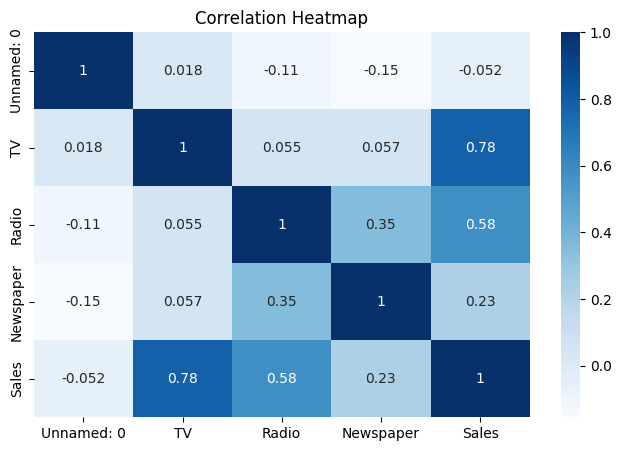

In [5]:
# correction heatmap
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(), annot=True, cmap='Blues')

plt.title("Correlation Heatmap")

plt.show()

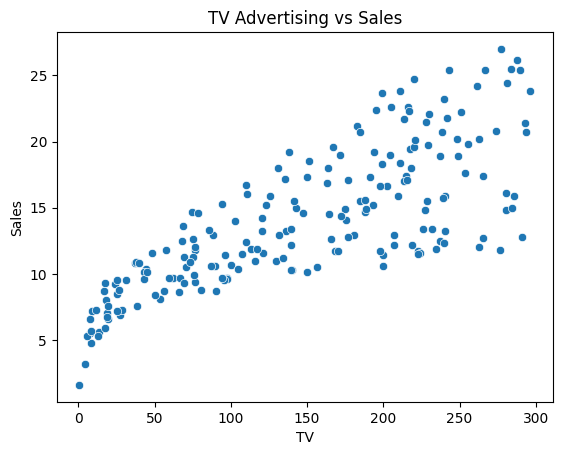

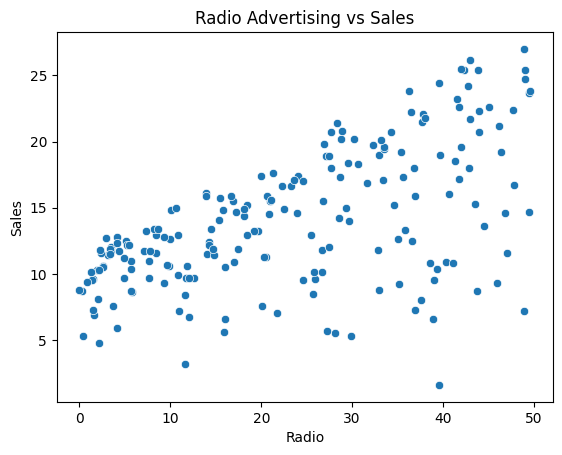

In [6]:
# TV vs sales 
sns.scatterplot(data=df, x='TV', y='Sales')

plt.title("TV Advertising vs Sales")

plt.show()

# radio vs sales
sns.scatterplot(data=df, x='Radio', y='Sales')

plt.title("Radio Advertising vs Sales")

plt.show()

In [7]:
# features selections
X = df[['TV', 'Radio', 'Newspaper']]

y = df['Sales']

# train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Regression model
model = LinearRegression()

model.fit(X_train, y_train)

# prediction
predictions = model.predict(X_test)

# used calculations
# Sales=w1​(TV)+w2​(Radio)+w3​(Newspaper)+b


MAE: 1.4607567168117603
R2 Score: 0.899438024100912
Predicted Sales: 20.45759025215365


/home/nitish/vs_code_cachy/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


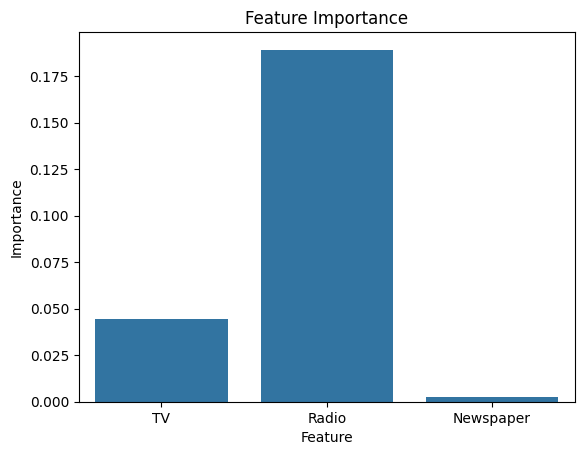

In [8]:
# module evalutions
mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("R2 Score:", r2)

# Future Sales Prediction
new_data = [[230, 37, 69]]

future_sales = model.predict(new_data)

print("Predicted Sales:", future_sales[0])

# Advertising impact analysis

features = X.columns

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.coef_
})

importance

# Feature Importance Graph
sns.barplot(
    x='Feature',
    y='Importance',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [9]:
# Business insights
print("Marketing Insights")

if model.coef_[0] > model.coef_[1]:
    print("TV advertising has higher impact on sales.")

else:
    print("Radio advertising performs better.")

print("Increase budget on top-performing platform.")


# save model
joblib.dump(model, "sales_model.pkl")

Marketing Insights
Radio advertising performs better.
Increase budget on top-performing platform.


['sales_model.pkl']